---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Alex Correia
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

In [1]:
%matplotlib widget
import numpy as np
import sympy

from ipywidgets import *
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

# Transmitted Field Dither Locking

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


## Plot of Fabry-Perot $E_\mathrm{refl}$ versus $E_\mathrm{trans}$

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?

From lecture, assuming a lossless Fabry-Perot (i.e. $\sqrt{r_1^2 + t_1^2} = 1$):
$$\frac{E_{refl}}{E_{in}} = \frac{r_1-r_2e^{-2i\phi}}{1-r_1r_2e^{-2i\phi}}$$
$$\frac{E_{trans}}{E_{in}} = \frac{t_1r_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}}.$$

In [2]:
def E_refl(phi, r1=0.9, r2=0.9):
    num = r1 - r2*np.exp(-2j*phi)
    den = 1 - r1*r2*np.exp(-2j*phi)
    return num/den

def E_trans(phi, r1=0.9, r2=0.9):
    t1 = np.sqrt(1 - r1*r1)
    num = t1*r2*np.exp(-1j*phi)
    den = 1 - r1*r2*np.exp(-2j*phi)
    return num/den

Text(0.5, 0, '$\\phi = kL$')

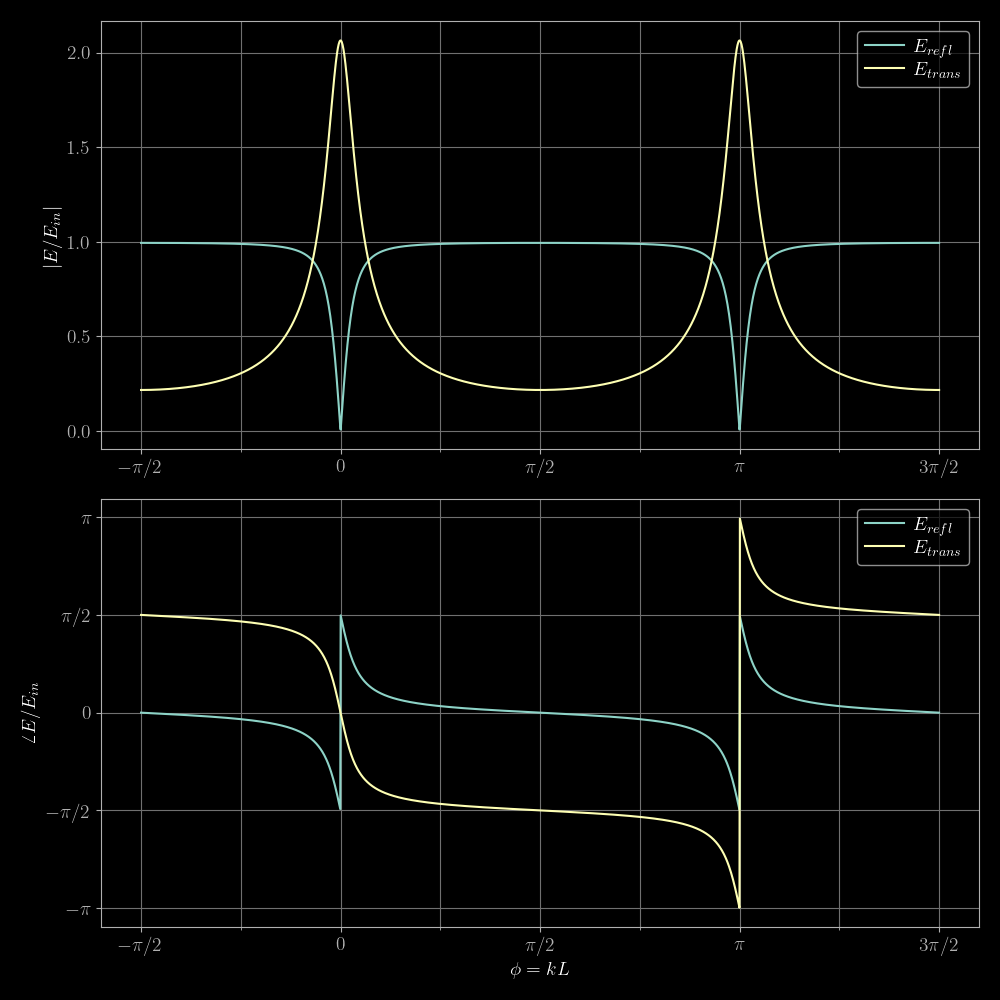

In [3]:
phis = np.linspace(-np.pi/2, 3*np.pi/2, 2000)

fig, ax = plt.subplots(2, figsize=(10,10))
ax[0].plot(phis, abs(E_refl(phis)), label=r'$E_{refl}$')
ax[0].plot(phis, abs(E_trans(phis)), label=r'$E_{trans}$')
ax[1].plot(phis, np.angle(E_refl(phis)), label=r'$E_{refl}$')
ax[1].plot(phis, np.angle(E_trans(phis)), label=r'$E_{trans}$')
#ax[1].plot(phis, np.arctan2(E_refl(phis).imag, E_refl(phis).real), label=r'$E_{refl}$')
#ax[1].plot(phis, np.arctan2(E_trans(phis).imag, E_trans(phis).real), label=r'$E_{trans}$')

ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', 0, r'$\pi/2$', r'$\pi$'])

for i in range(2):
    ax[i].set_xticks([-np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2], [r'$-\pi/2$', 0, r'$\pi/2$', r'$\pi$', r'$3\pi/2$'])
    ax[i].set_xticks([-np.pi/4, np.pi/4, 3*np.pi/4, 5*np.pi/4], minor=True)
    ax[i].grid(which='both')
    ax[i].legend()

ax[0].set_ylabel(r'$|E/E_{in}|$')
ax[1].set_ylabel(r'$\angle E/E_{in}$')
ax[1].set_xlabel(r'$\phi = kL$')

The sign of the argument of $E_{refl}$ is the same at both resonance points (i.e. 0 and $\pi$). However, the sign flips for $E_{trans}$; at $\phi = 0$, the imaginary part of the field has the opposite sign as it does at $\phi = \pi$.

## Total $E_\mathrm{trans}$ with end-mirror moduation 

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?

First, we calculate the field incident to the end mirror, which is equal to $E_{cav} / E_{in}$ propagated along the arm length $L = \phi/k$:
$$\frac{E_{cav}}{E_{in}} = \frac{t_1e^{-i\phi}}{1 - r_1r_2e^{-2i\phi}}.$$
At the end mirror, the carrier splits into three fields upon reflection due to the modulation, creating the internal cavity field $E_{cav2}$.  
$${E_{cav2}} = -r_2(1 + ik\Delta x e^{i\omega t} + ik\Delta x e^{-i\omega t}){E_{cav}}.$$
From the end mirror, the field will propagate in the cavity, eventually contributing to the transmitted field according to transfer function below (the fifth row, third column of Eq. 42 in the Fabry-Perot lecture):
$$\frac{E_{trans}}{E_{cav2}} = -\frac{r_1t_2e^{-2i\phi}}{1-r_1r_2e^{-2i\phi}}.$$
The resulting transmitted field will therefore have three components, corresponding to the carrier and two sidebands. The carrier field will transmit through the end mirror as normal:
\begin{align}
E_{trans}^0 &= \frac{E_{trans}}{E_{in}}(\phi)E_{in} \\
&= t_2 \frac{E_{cav}}{E_{in}}(\phi)E_{in}.
\end{align}
Both sidebands will transmit towards the mirror in the same way, but when propagating through the cavity will accrue different phases determined by $\eta = \omega L/c$. Specifically, the sideband contributions to the transmitted field will be
\begin{align}
E_{trans}^+ &= \frac{E_{trans}}{E_{cav2}}(\phi + \eta)\frac{E_{cav2}^+}{E_{cav}}\frac{E_{cav}}{E_{in}}(\phi)E_{in} \\
E_{trans}^- &= \frac{E_{trans}}{E_{cav2}}(\phi - \eta)\frac{E_{cav2}^-}{E_{cav}}\frac{E_{cav}}{E_{in}}(\phi)E_{in},
\end{align}
where the quantities $E_{cav2}^{\pm}$ correspond to the $\pm \omega$ terms in the full transfer function above. Writing the total transmitted field out explicitly:
\begin{align}
E_{trans} &= E_{trans}^0 + E_{trans}^+ + E_{trans}^- \\
&= E_0t_2e^{i\omega_0 t} \frac{E_{cav}}{E_{in}}(\phi) \bigg[ 1 + \frac{E_{trans}}{E_{cav2}}(\phi + \eta)\frac{E_{cav2}^+}{E_{cav}} + \frac{E_{trans}}{E_{cav2}}(\phi - \eta)\frac{E_{cav2}^-}{E_{cav}} \bigg] \\
E_{trans} &= E_0e^{i\omega_0 t}\frac{t_1t_2e^{-i\phi}}{1 - r_1r_2e^{-2i\phi}} \bigg[ 1 + ik\Delta x e^{i\omega t} \frac{r_1r_2e^{-2i(\phi + \eta)}}{1 - r_1r_2e^{-2i(\phi + \eta)}} + ik\Delta x e^{-i\omega t} \frac{r_1r_2e^{-2i(\phi - \eta)}}{1 - r_1r_2e^{-2i(\phi - \eta)}} \bigg].
\end{align}

## Calculate the total transmitted power $P_\mathrm{trans}(t)$

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

Splitting the field up into the three constituent fields and taking the modulus gives
\begin{align}
P_{trans} &= |E_{trans}^0 + E_{trans}^+ + E_{trans}^-|^2 \\
&= |E_{trans}^0|^2 + |E_{trans}^+|^2 + |E_{trans}^-|^2 + E_{trans}^0 E_{trans}^{*+} + E_{trans}^0 E_{trans}^{*-} + E_{trans}^+ E_{trans}^{*0} + E_{trans}^+ E_{trans}^{*-} + E_{trans}^- E_{trans}^{*+} + E_{trans}^- E_{trans}^{*0}.
\end{align}
The sideband terms are both linear in $\Delta x$, so any cross terms between sideband fields will go to zero in this approximation. Thus:
$$P_{trans} = |E_{trans}^0|^2 + E_{trans}^0 E_{trans}^{*+} + E_{trans}^0 E_{trans}^{*-} + E_{trans}^+ E_{trans}^{*0} + E_{trans}^- E_{trans}^{*0}.$$
This can be split into a DC term and a term that oscillates with frequency $\omega$:
$$P_{trans}^{DC} = |E_{trans}^0|^2 = E_0^2\frac{t_1^2t_2^2}{1 + r_1^2r_2^2 - 2r_1r_2\cos(2\phi)}$$
$$ P_{trans}^{1\omega} = E_{trans}^0 E_{trans}^{*+} + E_{trans}^0 E_{trans}^{*-} + E_{trans}^+ E_{trans}^{*0} + E_{trans}^- E_{trans}^{*0}.$$
The terms dependent on $\omega$ can be rewritten in terms of a complex number $ze^{i\omega t} = E_{trans}^{*0} E_{trans}^{+} + E_{trans}^0 E_{trans}^{*-}$. We can identify the remaining terms in the power as the conjugate $z^*e^{-i\omega t}$.

## Calculate the transmitted power demodulated at $\omega$ 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

If we expand out the demodulation formula:
\begin{align}
P_{trans}(\omega) &= \frac{1}{2\pi}\int_0^{2\pi}P_{trans} e^{i\omega t} d(\omega t) \\
&= \frac{1}{2\pi}\int_0^{2\pi}P_{trans} (\cos \omega t + i\sin \omega t) d(\omega t) \\
&= P^I + iP^Q
\end{align}
Examining the integrand of the first line, we notice that the DC term will gain a dependence $e^{i\omega t}$, and the term proportional to $z$ will gain a dependence $e^{2i\omega t}$. Both of these integrate to zero over a full period, so the only remaining term will be $z^*$ with the dependence on $\omega$ pulled out. Thus,
$$P_{trans}(\omega) &= [E_{trans}^0E_{trans}^{*+} + E_{trans}^- E_{trans}^{*0}]e^{i\omega t}.$$
Using the definitions from above
\begin{align}
E_{trans}^0 &= E_0e^{i\omega_0 t}\frac{t_1t_2e^{-i\phi}}{1 - r_1r_2e^{-2i\phi}} \\
E_{trans}^+ &= ik\Delta xE_0e^{i(\omega_0 + \omega) t} \frac{t_1t_2e^{-i\phi}}{1 - r_1r_2e^{-2i\phi}} \frac{r_1r_2e^{-2i(\phi + \eta)}}{1 - r_1r_2e^{-2i(\phi + \eta)}} \\
E_{trans}^- &= ik\Delta xE_0e^{i(\omega_0 - \omega) t} \frac{t_1t_2e^{-i\phi}}{1 - r_1r_2e^{-2i\phi}} \frac{r_1r_2e^{-2i(\phi - \eta)}}{1 - r_1r_2e^{-2i(\phi - \eta)}},
\end{align}
we can rewrite the demodulated power as
\begin{align}
P_{trans}(\omega) = ik\Delta xE_0^2\frac{t_1^2t_2^2r_1r_2}{1 + r_1^2r_2^2 - 2r_1r_2\cos(2\phi)}\bigg[ \frac{e^{-2i(\phi - \eta)}}{1 - r_1r_2e^{-2i(\phi - \eta)}} - \frac{e^{2i(\phi + \eta)}}{1 - r_1r_2e^{2i(\phi + \eta)}} \bigg]
\end{align}

## Plot the length to transmitted power function phase sweep
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

In [4]:
def Ptrans(phi, omega, L=1, Pin=1, T1=0.3, T2=0.3, lam=1064):
    k = 2*np.pi / lam # wave number
    r1 = np.sqrt(1 - T1) # mirror 1 reflectivity
    r2 = np.sqrt(1 - T2) # mirror 2 reflectivity
    eta = omega * L / 3e8 # sideband phase
    pref = 1j*k*Pin*(T1*T2*r1*r2)/(1 + r1*r1*r2*r2 - 2*r1*r2*np.cos(2*phi))
    pterm = np.exp(-2j*(phi - eta))/(1 - r1*r2*np.exp(-2j*(phi - eta)))
    mterm = np.exp(2j*(phi + eta))/(1 - r1*r2*np.exp(2j*(phi + eta)))
    return pref * (pterm - mterm)

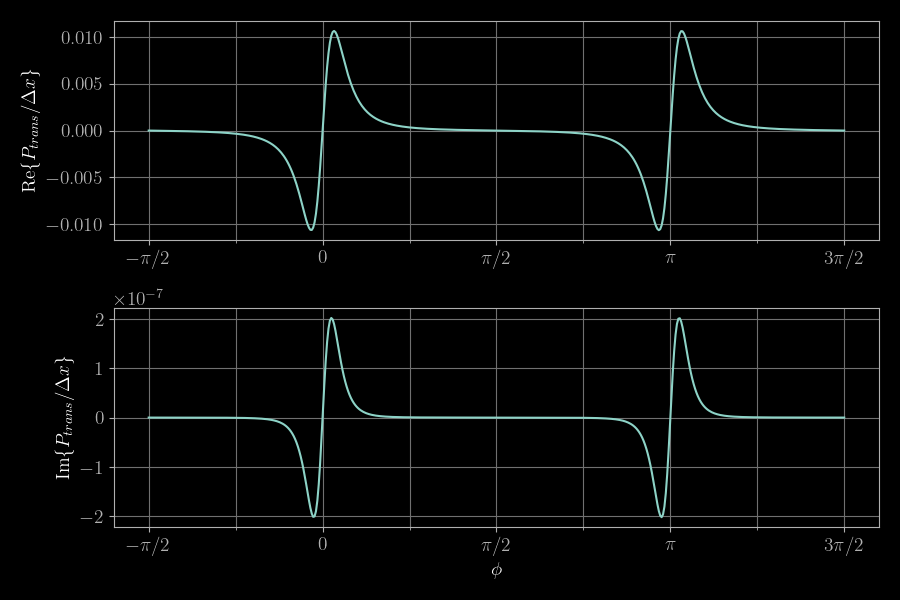

In [5]:
phis = np.linspace(-np.pi/2, 3*np.pi/2, 500)
fig, ax = plt.subplots(2)
ax[0].plot(phis, Ptrans(phis, 200*np.pi).real)
ax[1].plot(phis, Ptrans(phis, 200*np.pi).imag)

ax[0].set_ylabel(r'$\mathrm{Re}\{P_{trans}/\Delta x\}$')
ax[1].set_ylabel(r'$\mathrm{Im}\{P_{trans}/\Delta x\}$')
ax[1].set_xlabel(r'$\phi$')

for i in range(2):
    ax[i].set_xticks([-np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2], [r'$-\pi/2$', 0, r'$\pi/2$', r'$\pi$', r'$3\pi/2$'])
    ax[i].set_xticks([-np.pi/4, np.pi/4, 3*np.pi/4, 5*np.pi/4], minor=True)
    ax[i].grid(which='both')

## Plot the length to transmitted power transfer function

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

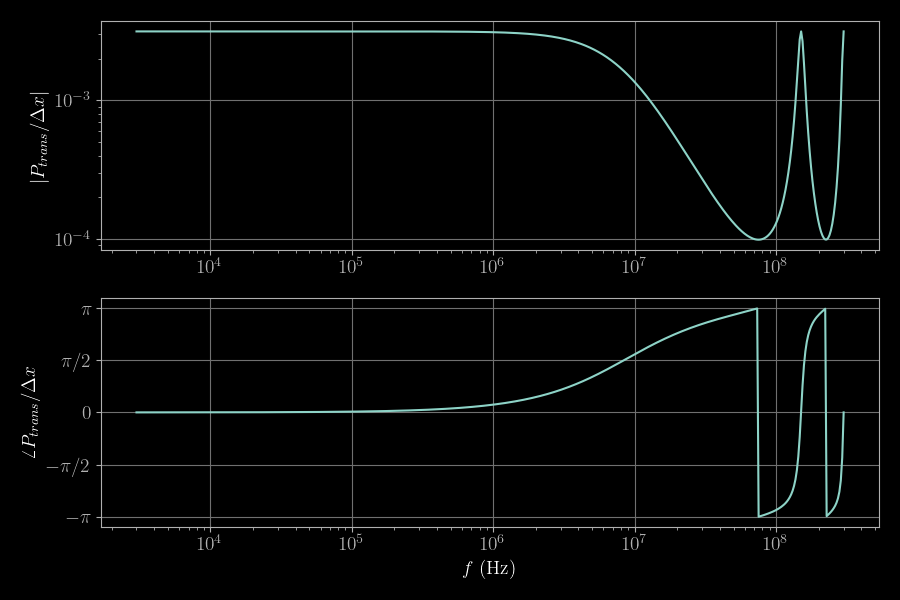

In [6]:
freqs = np.logspace(np.log10(3e3), np.log10(3e8), 500)
fig, ax = plt.subplots(2)
ax[0].loglog(freqs, abs(Ptrans(np.pi/180, 2*np.pi*freqs)))
ax[1].semilogx(freqs, np.angle(Ptrans(np.pi/180, 2*np.pi*freqs)))

ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', 0, r'$\pi/2$', r'$\pi$'])

ax[0].set_ylabel(r'$|P_{trans}/\Delta x|$')
ax[1].set_ylabel(r'$\angle P_{trans}/\Delta x $')
ax[1].set_xlabel(r'$f~\mathrm{(Hz)}$')

for i in range(2):
    ax[i].grid()

# Pound-Drever-Hall Michelson

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

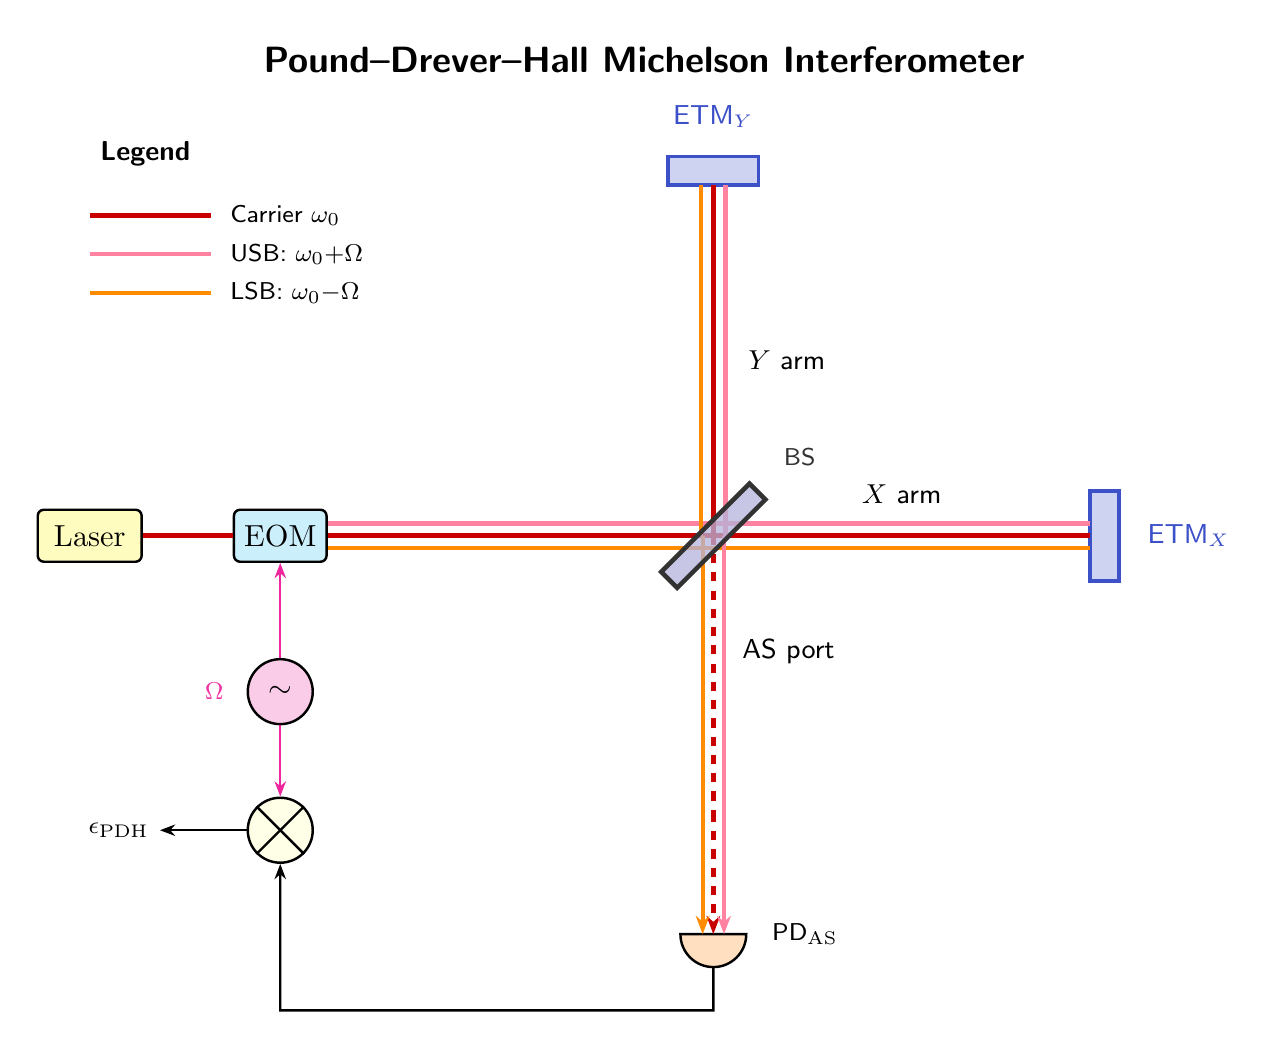

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

Given our carrier input field
$$E_{in}^0 = E_0e^{i\omega_0 t},$$
we apply a modulation of depth $\Omega$ and frequency $\Omega$:
$$E_{in} = E_0e^{i\omega t} \bigg[ 1 + ik\frac{\Gamma}{2} e^{i\Omega t} + ik\frac{\Gamma}{2} e^{-i\Omega t} \bigg].$$
The carrier experiences CARM and DARM phases
\begin{align}
\phi_c &= \frac{\omega_0(L_x + L_y)}{c} \\
\phi_d &= \frac{\omega_0(L_x - L_y)}{c}, \\
\end{align}
while the upper and lower sidebands experience phases
\begin{align}
\phi_c \pm \varphi_c &= \frac{(\omega_0 \pm \Omega)(L_x + L_y)}{c} \\
\phi_d \pm \varphi_d &= \frac{(\omega_0 \pm \Omega)(L_x - L_y)}{c}. \\
\end{align}
We can propagate the three fields through the Michelson using the regular transfer function
$$\frac{E_{as}}{E_{in}}(\omega) = r_{bs}t_{bs}\bigg[ r_ye^{-2i\omega L_y/c} - r_xe^{-2i\omega L_x/c} \bigg].$$
If we assume the end mirrors have the same reflectivity $r_x = r_y$, this can be rewritten as
$$\frac{E_{as}}{E_{in}}(\omega) = -2ir_{bs}t_{bs}r_xe^{i\omega(L_x + L_y)/c}\sin (\omega(L_x - L_y)/c),$$
and substituting in the modulated input field gives
\begin{align}
E_{as} &= E_0 e^{i\omega_0 t}\bigg[  \frac{E_{as}}{E_{in}}(\omega_0) + ik\frac{\Gamma}{2} e^{i\Omega t}\frac{E_{as}}{E_{in}}(\omega_0 + \Omega) + ik\frac{\Gamma}{2} e^{-i\Omega t}\frac{E_{as}}{E_{in}}(\omega_0 - \Omega) \bigg] \\
&= -2iE_0 r_{bs}t_{bs}r_y e^{i\omega_0 t}e^{-i\phi_c}\bigg[ \sin \phi_d + ik\frac{\Gamma}{2} e^{i\Omega t}e^{-i\varphi_c}\sin(\phi_d + \varphi_d) + ik\frac{\Gamma}{2} e^{-i\Omega t}e^{i\varphi_c}\sin(\phi_d - \varphi_d) \bigg]
\end{align}
If the DARM offset $L_x - L_y = 0$, all the fields above also go to zero, and the AS port is completely dark. Thus we need some nonzero DARM offset for PDH locking.

## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

Expanding out the expression above fully:
\begin{align}
P_{as} = 4E_0^2r_{bs}^2t_{bs}^2r_x^2\bigg[ &\sin^2 \phi_d - ik\frac{\Gamma}{2}e^{-i\Omega t}e^{i\varphi_c}\sin\phi_d \sin(\phi_d + \varphi_d) - ik\frac{\Gamma}{2}e^{i\Omega t}e^{-i\varphi_c}\sin\phi_d \sin(\phi_d - \varphi_d) \\
&+ ik\frac{\Gamma}{2}e^{i\Omega t}e^{-i\varphi_c}\sin\phi_d \sin(\phi_d + \varphi_d) + k^2 \frac{\Gamma^2}{4} \sin^2 (\phi_d + \varphi_d) + k^2 \frac{\Gamma^2}{4}e^{2i\Omega t}e^{-2i\varphi_c}\sin(\phi_d + \varphi_d)\sin(\phi_d - \varphi_d) \\
&+ ik\frac{\Gamma}{2}e^{-i\Omega t}e^{i\varphi_c}\sin\phi_d \sin(\phi_d - \varphi_d) + k^2 \frac{\Gamma^2}{4}e^{-2i\Omega t}e^{2i\varphi_c}\sin(\phi_d + \varphi_d)\sin(\phi_d - \varphi_d) + k^2 \frac{\Gamma^2}{4} \sin^2 (\phi_d - \varphi_d) \bigg].
\end{align}
If we omit terms quadratic in $\Gamma$,
\begin{align}
P_{as} = 4E_0^2r_{bs}^2t_{bs}^2r_x^2\bigg[ &\sin^2 \phi_d + ik\frac{\Gamma}{2}e^{-i\Omega t}e^{i\varphi_c}\sin\phi_d (\sin(\phi_d - \varphi_d) - \sin(\phi_d + \varphi_d)) \\
&+ ik\frac{\Gamma}{2}e^{i\Omega t}e^{-i\varphi_c}\sin\phi_d (\sin(\phi_d + \varphi_d) - \sin(\phi_d - \varphi_d))  \bigg].
\end{align}
Finally, simplifying the trig functions,
\begin{align}
P_{as} &= 4E_0^2r_{bs}^2t_{bs}^2r_x^2\bigg[ \sin^2 \phi_d - ik\frac{\Gamma}{2} e^{-i\Omega t}e^{i\varphi_c}2\sin\phi_d \cos\phi_d\sin \varphi_d + ik\frac{\Gamma}{2} e^{i\Omega t}e^{-i\varphi_c}2\sin\phi_d \cos\phi_d \sin\varphi_d \bigg] \\
&= 4E_0^2r_{bs}^2t_{bs}^2r_x^2\sin^2\phi_d\bigg[ 1 - ik\frac{\Gamma}{2} e^{-i\Omega t}e^{i\varphi_c}\sin \varphi_d + ik\frac{\Gamma}{2} e^{i\Omega t}e^{-i\varphi_c}\sin\varphi_d \bigg].
\end{align}
We recognize three terms, corresponding to the carrier, lower sideband, and upper sideband from left to right.

## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?

If we examine $P_{as}$, we notice a DC term independent of $\Omega$, as well as sideband terms proportional to $e^{i\Omega t}$ and $e^{-i\Omega t}$. When taking the demodulation integral
$$P_{as} = \frac{1}{2\pi}\int_0^{2\pi}P_{as}e^{i\Omega t}d(\Omega t),$$
the DC and $e^{i\Omega t}$ terms will integrate to zero over a full period, leaving only the coefficient of the $e^{-i\Omega t}$ term as the final result:
$$P_{as} (\phi_d, \varphi_d) = -2ik\Gamma E_0^2r_{bs}^2t_{bs}^2r_x^2\sin^2\phi_d e^{i\varphi_c}\sin \varphi_d.$$
If we assume $r_{bs} = t_{bs} = 1/\sqrt{2}$ and $r_x = r_y = 1$, and define the input power $P_{in} = E_0^2$, we obtain
$$\frac{P_{as}}{P_{in}} = -ik\frac{\Gamma}{2}e^{i\varphi_c}\sin^2\phi_d \sin \varphi_d.$$
For the plots below, we assume macroscopic arm lengths $L_x^0 = L_y^0 = 5~\mathrm{m}$, with a differential change in length $\delta L$ that determines the overall phases. Specifically, if we define
\begin{align}
L_x &= L_x^0 + \frac{\delta L}{2} \\
L_y &= L_y^0 - \frac{\delta L}{2},
\end{align}
we can rewrite the phases as
\begin{align}
\phi_d &= \frac{\omega_0(L_x^0 - L_y^0 + \delta L)}{c} \\
\phi_c &= \frac{\omega_0(L_x^0 + L_y^0)}{c}.
\end{align}

In [7]:
def P_as(phi, Lx=5, Ly=5, omega0=2*np.pi*100*1e6, omega=2*np.pi*200*1e6):
    c = 3e8 # speed of light
    k = omega0 / c # carrier wavenumber
    phi_len = phi / k # length change corresponding to input phi
    phi_d = k * (Lx - Ly + phi_len) # carrier DARM phase
    phi_c = k * (Lx + Ly) # carrier CARM phase
    varphi_d = omega * (Lx - Ly + phi_len) / c # sideband DARM phase
    varphi_c = omega * (Lx + Ly) / c # sideband CARM phase
    return -1j * k / 2 * np.exp(1j*varphi_c) * np.sin(phi_d)**2 * np.sin(varphi_d)

Text(0.5, 0, '$\\phi_d$')

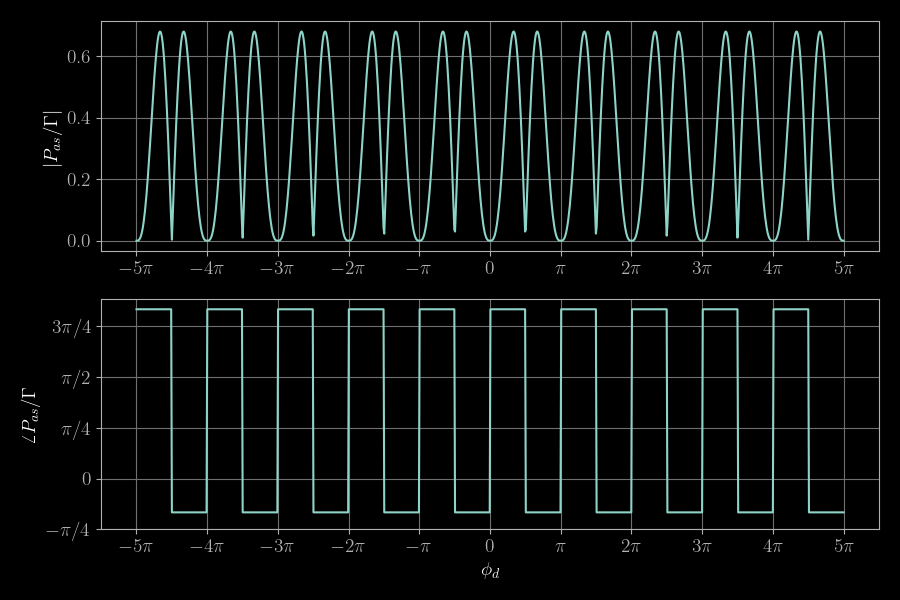

In [8]:
phis = np.linspace(-5*np.pi, 5*np.pi, 1000)

fig, ax = plt.subplots(2)
ax[0].plot(phis, abs(P_as(phis)))
ax[1].plot(phis, np.angle(P_as(phis)))

for i in range(2):
    ax[i].set_xticks([-(5-i)*np.pi for i in range(11)], [r'$-5\pi$', r'$-4\pi$', r'$-3\pi$', r'$-2\pi$', r'$-\pi$',
                                                        0, r'$\pi$',r'$2\pi$',r'$3\pi$',r'$4\pi$',r'$5\pi$',])
    ax[i].grid()
ax[1].set_yticks([-np.pi/4, 0, np.pi/4, np.pi/2, 3*np.pi/4], [r'$-\pi/4$', 0, r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$'])

ax[0].set_ylabel(r'$|P_{as}/\Gamma|$')
ax[1].set_ylabel(r'$\angle P_{as}/\Gamma$')
ax[1].set_xlabel(r'$\phi_d$')

When off-resonance, the argument of the power is a constant value, either positive or negative. When near resonance, the sign of the argument flips signs. Specifically, as $\phi_d$ increases near a resonance point, the sign of the argument flips from negative to positive. So, if the interferometer is slightly off-alignment, the sign of the argument tells whether the DARM carrier phase needs to be increased or decreased, which would be indicated by the power argument being negative or positive respectively.

# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

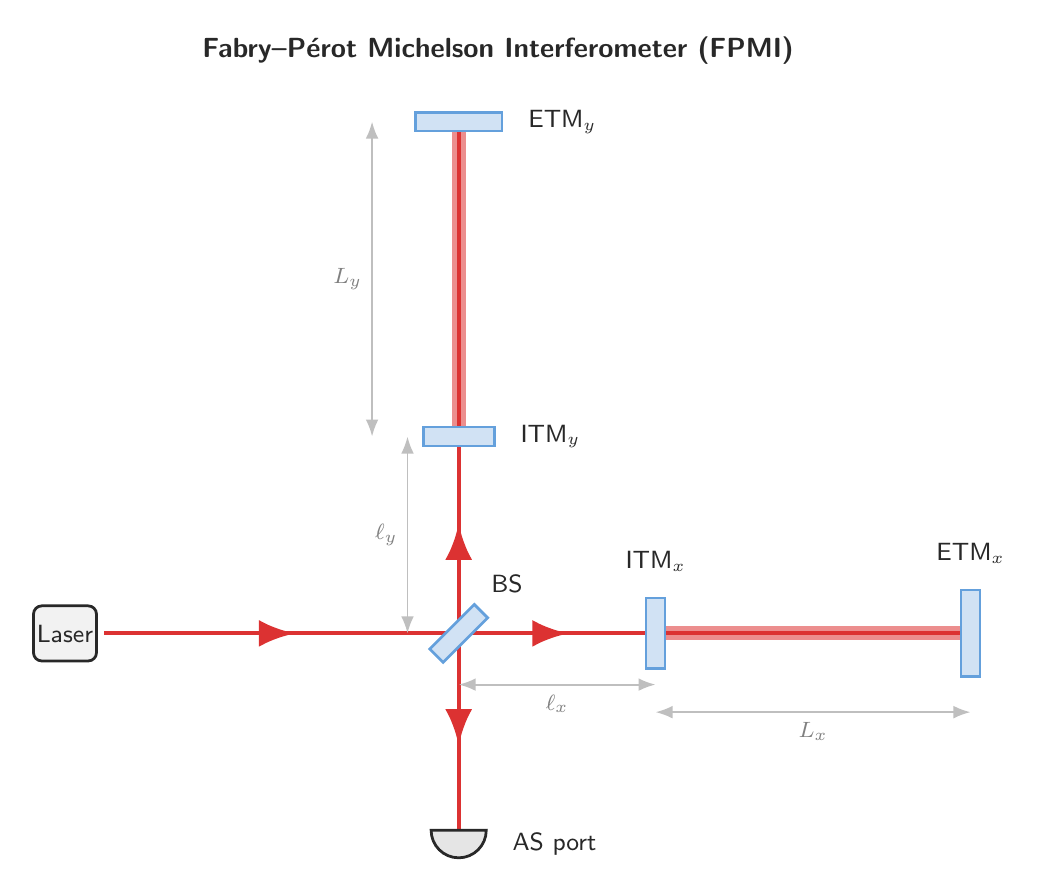

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

We can depict the above system using the directed graph below.

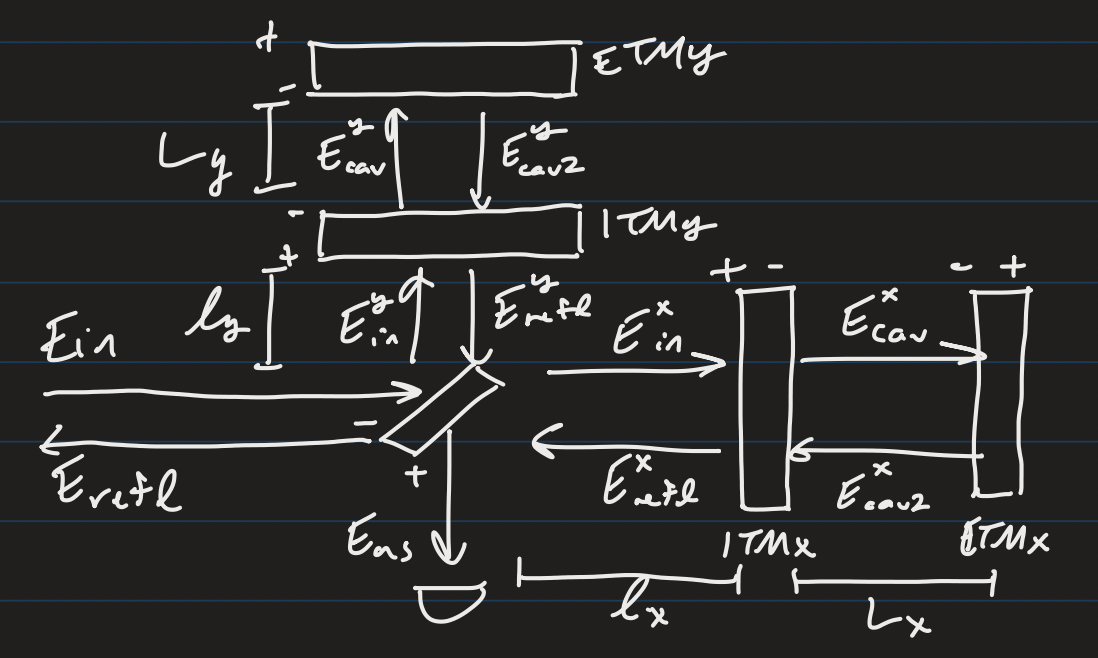

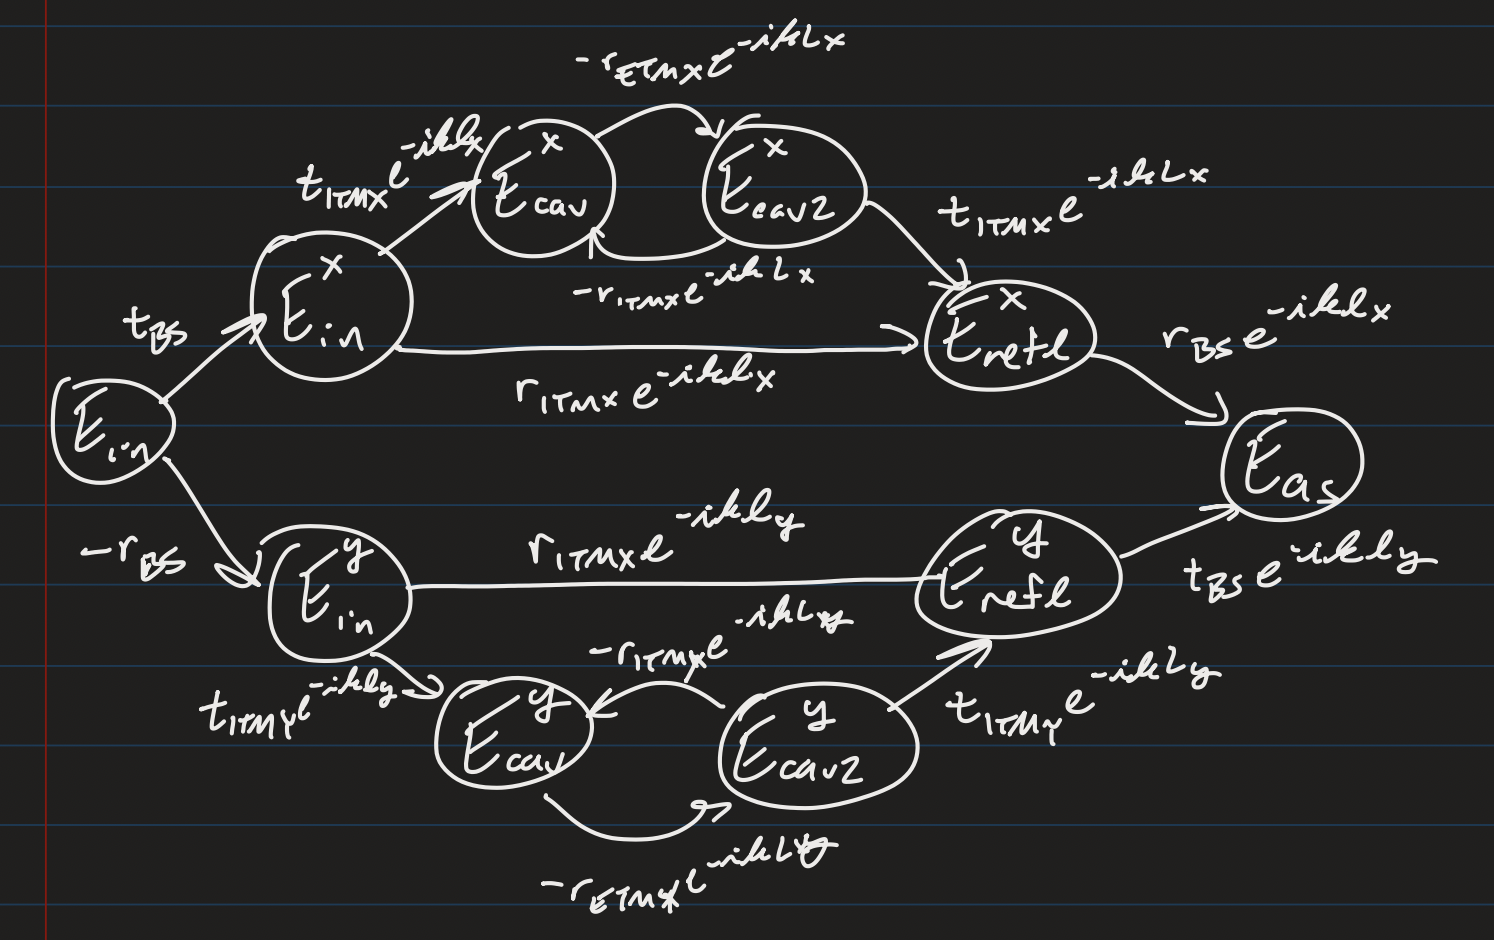

Writing this as an adjacency matrix and making the substitutions for $\phi_i$ and $\Phi_i$ above gives
$$\begin{bmatrix}
E_{in} \\
E^x_{in} \\
E^y_{in} \\
E^x_{cav} \\
E^y_{cav} \\
E^x_{cav2} \\
E^y_{cav2} \\
E^x_{refl} \\
E^y_{refl} \\
E_{as} \\
\end{bmatrix} = \begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
t_{bs} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
-r_{bs} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & t_{itmx}e^{-i\phi_x} & 0 & 0 & 0 & -r_{itmx}e^{-i\Phi_x} & 0 & 0 & 0 & 0 \\
0 & 0 & t_{itmy}e^{-i\phi_y} & 0 & 0 & 0 & -r_{itmy}e^{-i\Phi_y} & 0 & 0 & 0 \\
0 & 0 & 0 & -r_{etmx}e^{-i\Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & -r_{etmy}e^{-i\Phi_y} & 0 & 0 & 0 & 0 & 0 \\
0 & r_{itmx}e^{-i\phi_x} & 0 & 0 & 0 & t_{itmx}e^{-i\Phi_x} & 0 & 0 & 0 & 0 \\
0 & 0 & r_{itmy}e^{-i\phi_y} & 0 & 0 & 0 & t_{itmy}e^{-i\Phi_y} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{bs}e^{-i\phi_x} & t_{bs}e^{-i\phi_y} & 0 \\
\end{bmatrix}\begin{bmatrix}
E_{in} \\
E^x_{in} \\
E^y_{in} \\
E^x_{cav} \\
E^y_{cav} \\
E^x_{cav2} \\
E^y_{cav2} \\
E^x_{refl} \\
E^y_{refl} \\
E_{as} \\
\end{bmatrix}$$

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

Using sympy for the inversion:

In [9]:
phi_x, phi_y, Phi_x, Phi_y = sympy.symbols('\phi_x \phi_y \Phi_x \Phi_y', real=True)
r_bs, t_bs, r_itmx, t_itmx, r_itmy, t_itmy, r_etmx, t_etmx, r_etmy, t_etmy = sympy.symbols('r_{bs} t_{bs} r_{itmx} t_{itmx} r_{itmy} t_{itmy} r_{etmx} t_{etmx} r_{etmy} t_{etmy}',
                                                                                            positive=True, real=True)

# construct the matrix I - A, A is given above
mat = sympy.Matrix([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                    [-t_bs, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                    [r_bs, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                    [0, -t_itmx*sympy.exp(-1j*phi_x), 0, 1, 0, r_itmx*sympy.exp(-1j*Phi_x), 0, 0, 0, 0],
                    [0, 0, -t_itmy*sympy.exp(-1j*phi_y), 0, 1, 0, r_itmy*sympy.exp(-1j*Phi_y), 0, 0, 0],
                    [0, 0, 0, r_etmx*sympy.exp(-1j*Phi_x), 0, 1, 0, 0, 0, 0],
                    [0, 0, 0, 0, r_etmy*sympy.exp(-1j*Phi_y), 0, 1, 0, 0, 0],
                    [0, -r_itmx*sympy.exp(-1j*phi_x), 0, 0, 0, -t_itmx*sympy.exp(-1j*Phi_x), 0, 1, 0, 0],
                    [0, 0, -r_itmy*sympy.exp(-1j*phi_y), 0, 0, 0, -t_itmy*sympy.exp(-1j*Phi_y), 0, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, -r_bs*sympy.exp(-1j*phi_x), -t_bs*sympy.exp(-1j*phi_y), 1]])

sympy.simplify(-mat) # take negative to check if signs are consistent with above

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
/var/folders/_r/9j158hjs4_1b8tq_l4bjwk340000gn/T/ipykernel_73608/983596106.py:1: SyntaxWarning: invalid escape sequence '\p'
  phi_x, phi_y, Phi_x, Phi_y = sympy.symbols('\phi_x \phi_y \Phi_x \Phi_y', real=True)


Matrix([
[     -1,                           0,                           0,                            0,                            0,                            0,                            0,                         0,                         0,  0],
[ t_{bs},                          -1,                           0,                            0,                            0,                            0,                            0,                         0,                         0,  0],
[-r_{bs},                           0,                          -1,                            0,                            0,                            0,                            0,                         0,                         0,  0],
[      0, t_{itmx}*exp(-1.0*I*\phi_x),                           0,                           -1,                            0, -r_{itmx}*exp(-1.0*I*\Phi_x),                            0,                         0,                         0,  0],
[  

In [10]:
#invert
invmat = mat**-1
Eas = sympy.simplify(invmat[9,0])
Eas

r_{bs}*t_{bs}*(r_{etmx}*r_{etmy}*r_{itmx}**2*r_{itmy}*exp(2.0*I*\phi_y) - r_{etmx}*r_{etmy}*r_{itmx}*r_{itmy}**2*exp(2.0*I*\phi_x) - r_{etmx}*r_{etmy}*r_{itmx}*t_{itmy}**2*exp(2.0*I*\phi_x) + r_{etmx}*r_{etmy}*r_{itmy}*t_{itmx}**2*exp(2.0*I*\phi_y) - r_{etmx}*r_{itmx}**2*exp(2.0*I*(\Phi_y + \phi_y)) + r_{etmx}*r_{itmx}*r_{itmy}*exp(2.0*I*(\Phi_y + \phi_x)) - r_{etmx}*t_{itmx}**2*exp(2.0*I*(\Phi_y + \phi_y)) - r_{etmy}*r_{itmx}*r_{itmy}*exp(2.0*I*(\Phi_x + \phi_y)) + r_{etmy}*r_{itmy}**2*exp(2.0*I*(\Phi_x + \phi_x)) + r_{etmy}*t_{itmy}**2*exp(2.0*I*(\Phi_x + \phi_x)) + r_{itmx}*exp(2.0*I*(\Phi_x + \Phi_y + \phi_y)) - r_{itmy}*exp(2.0*I*(\Phi_x + \Phi_y + \phi_x)))*exp(-2.0*I*(\phi_x + \phi_y))/(r_{etmx}*r_{etmy}*r_{itmx}*r_{itmy} - r_{etmx}*r_{itmx}*exp(2.0*I*\Phi_y) - r_{etmy}*r_{itmy}*exp(2.0*I*\Phi_x) + exp(2.0*I*\Phi_x + 2.0*I*\Phi_y))

## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

In [11]:
# doing the trivial substitutions (i.e. "x = y")
Eas_subbed = Eas.subs([(phi_x, 0), (phi_y, 0), (r_bs, 1/sympy.sqrt(2)), (t_bs, 1/sympy.sqrt(2)), 
                       (r_itmy, r_itmx), (t_itmy, t_itmx), (r_etmy, r_etmx), (t_etmy, t_etmx)])
sympy.simplify(Eas_subbed)

r_{etmx}*t_{itmx}**2*(exp(2.0*I*\Phi_x) - exp(2.0*I*\Phi_y))/(2*(r_{etmx}**2*r_{itmx}**2 - r_{etmx}*r_{itmx}*exp(2.0*I*\Phi_x) - r_{etmx}*r_{itmx}*exp(2.0*I*\Phi_y) + exp(2.0*I*(\Phi_x + \Phi_y))))

In [12]:
# now do a change of basis
Phi_c, Phi_d = sympy.symbols('\Phi_c \Phi_d', real=True)
Eas_darm = Eas_subbed.subs([(Phi_x, Phi_c + Phi_d), (Phi_y, Phi_c - Phi_d)])
sympy.simplify(Eas_darm)

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
/var/folders/_r/9j158hjs4_1b8tq_l4bjwk340000gn/T/ipykernel_73608/4039457662.py:2: SyntaxWarning: invalid escape sequence '\P'
  Phi_c, Phi_d = sympy.symbols('\Phi_c \Phi_d', real=True)


r_{etmx}*t_{itmx}**2*(-exp(2.0*I*(\Phi_c - \Phi_d)) + exp(2.0*I*(\Phi_c + \Phi_d)))/(2*(r_{etmx}**2*r_{itmx}**2 - r_{etmx}*r_{itmx}*exp(2.0*I*(\Phi_c - \Phi_d)) - r_{etmx}*r_{itmx}*exp(2.0*I*(\Phi_c + \Phi_d)) + exp(4.0*I*\Phi_c)))

We can break up the exponentials to get
$$\frac{E_{as}}{E_{in}} = \frac{r_{etmx}t^2_{itmx}ie^{2i\Phi_c}\sin(2\Phi_d)}
                               {r_{etmx}^2 r_{itmx}^2 - 2r_{etmx}r_{itmx}e^{2i\Phi_c}\cos(2\Phi_d) + e^{4i\Phi_c}}.$$

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}

As above, we can define the phases in terms of differential length changes
\begin{align}
\Phi_d &= \omega (L_x - L_y)/c + \delta \Phi_d \\
\Phi_c &= \omega(L_x + L_y)/c.
\end{align}

We plot this against the regular Michelson AS port
$$\frac{E_{trans}}{E_{in}} = -ir_{bs}t_{bs}r_xe^{-i\phi_c}\sin\phi_d,$$
where we assume equal reflectivity end mirrors $r_x = r_y$.

In [13]:
def E_as(omega, phi_d, Lx = 4000, Ly = 4000, r_etmx = 1, r_itmx = np.sqrt(1 - 0.1)):
    c = 3e8
    t_etmx = np.sqrt(1 - r_etmx*r_etmx) # transmission of end mirrors
    t_itmx = np.sqrt(1 - r_itmx*r_itmx) # transmission of start mirrors
    Phi_d = omega * (Lx - Ly) / c + phi_d # DARM phase
    Phi_c = omega * (Lx + Ly) / c # CARM phase
    num = r_etmx * t_itmx * t_itmx * 1j * np.exp(-2j*Phi_c) * np.sin(2*Phi_d)
    den = r_etmx**2 * r_itmx**2 - 2*r_etmx * r_itmx * np.exp(2j*Phi_c) * np.cos(2*Phi_d) + np.exp(4j*Phi_c)
    return num/den

In [14]:
def E_as_reg(omega, phi_d, Lx = 4000, Ly = 4000, r_bs = 1/np.sqrt(2), r_x = 1):
    '''The AS port field of a regular Michelson (i.e. no FP arms).
    Assumes equal reflectivity end mirrors r_x = r_y.
    '''
    c = 3e8
    Phi_d = omega * (Lx - Ly) / c + phi_d # DARM phase
    Phi_c = omega * (Lx + Ly) / c # CARM phase
    return -1j * r_bs * np.sqrt(1 - r_bs * r_bs) * r_x * np.exp(-1j * Phi_c) * np.sin(Phi_d)

Text(0.5, 0, '$\\phi_d$')

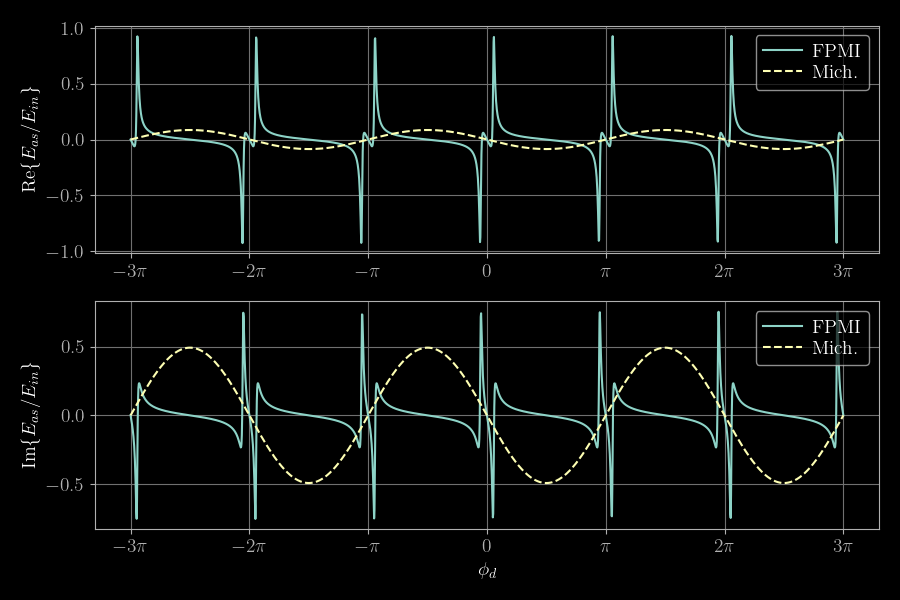

In [15]:
omega = 2*np.pi*1024 # frequency of input
phis = np.linspace(-3*np.pi, 3*np.pi, 2000)

fig, ax = plt.subplots(2)
ax[0].plot(phis, E_as(omega, phis).real, label='FPMI')
ax[0].plot(phis, E_as_reg(omega, phis).real, linestyle='--', label='Mich.')
ax[1].plot(phis, E_as(omega, phis).imag, label='FPMI')
ax[1].plot(phis, E_as_reg(omega, phis).imag, linestyle='--', label='Mich.')

for i in range(2):
    ax[i].set_xticks([-(3-i)*np.pi for i in range(7)], [r'$-3\pi$', r'$-2\pi$', r'$-\pi$',
                                                        0, r'$\pi$',r'$2\pi$',r'$3\pi$'])
    ax[i].grid()
    ax[i].legend()

ax[0].set_ylabel(r'$\mathrm{Re} \{E_{as}/E_{in} \}$')
ax[1].set_ylabel(r'$\mathrm{Im} \{E_{as}/E_{in} \}$')
ax[1].set_xlabel(r'$\phi_d$')

Examining the plot above, the Fabry-Perot Michelson is much more sensitive to changes in DARM phase than a regular Michelson interferometer. Specifically, the rate of change of the field magnitude is much sharper and occurs over a smaller domain of DARM phase values for the FPMI.

Additionally, the FPMI has secondary points where the AS port is completely dark at half intervals of $\pi$, where in a regular Michelson the power would be maximized. There also appears to be tertiary crossing points much closer to resonance (i.e. near but not exactly on intervals of $\pi$); thus, due to the sensitivity near resonance to DARM, one would have to be much closer to resonance in an FPMI to be sure that the interfometer is properly locked.